In [7]:
import matplotlib.pyplot as plt
import numpy as np
import psopy.minimize as minimize
from scipy.optimize import rosen
from psopy import init_feasible

In [8]:
### first we need to implement pso algorithm 

def pso(f, lb, ub, dim, n_particles, n_iter,x0 = None, ax=None):
    # f: function to minimize
    # lb: lower bound
    # ub: upper bound
    # dim: number of dimensions
    # n_particles: number of particles
    # n_iter: number of iterations
    
    # initialize the particles
    particles = np.random.uniform(lb, ub, (n_particles, dim))
    if x0 is not None:
        particles[0] = x0
    # initialize the velocities
    velocities = np.zeros((n_particles, dim))
    # initialize the best position
    best_position = particles
    # initialize the best value
    best_value = np.inf*np.ones(n_particles)
    # initialize the global best position
    global_best_position = np.zeros(dim)
    # initialize the global best value
    global_best_value = np.inf

    omega = 1
    damping = 0.97
    
    for i in range(n_iter):
        for j in range(n_particles):
            # evaluate the function
            value = f(particles[j])
            # update the best value
            if value < best_value[j]:
                best_value[j] = value
                best_position[j] = particles[j]
            # update the global best value
            if value < global_best_value:
                global_best_value = value
                global_best_position = particles[j]
            # update the velocities
            velocities[j] = omega*velocities[j] + 1.49*np.random.rand()*(best_position[j] - particles[j]) + 1.49*np.random.rand()*(global_best_position - particles[j])
            # update the particles
            particles[j] = particles[j] + 0.1*velocities[j]
            # check the bounds
            particles[j] = np.maximum(particles[j], lb)
            particles[j] = np.minimum(particles[j], ub)
            velocities[j] = np.maximum(velocities[j], lb)
            velocities[j] = np.minimum(velocities[j], ub)
            omega = omega*damping
        if ax is not None:
            ax.scatter(global_best_position[0], global_best_position[1], c='g', s=10)
    return global_best_position, global_best_value



In [9]:
def manage_batteries(SoE: float,
                     P_fv: float,
                     P_demanded: float,
                     P_pump: float) -> tuple[float, float, float, float]:
        """
        Choose the power to re/discharge the batteries and computes the next SoE
        :param SoE:
        :param P_fv:
        :param P_demanded:
        :param P_pump:
        :return:
        """
        SoE_max = 80
        SoE_min = 20
        n_d = 1.15
        n_c = 0.85  
        Pbat_max = 30
        

        E_surplus = 0
        E_deficit = 0
        Pbat = P_fv - P_demanded - P_pump
        if not -Pbat_max <= Pbat <= Pbat_max:  # The surplus is under the power of power bounds of the battery
            P_not_used = Pbat - np.clip(Pbat, -Pbat_max,
                                        Pbat_max)  # positive for surplus, negative for deficit
            Pbat = np.clip(Pbat, -Pbat_max, Pbat_max)
        else:
            P_not_used = 0
        delta_SoE = np.max([Pbat, 0]) * n_c * (1/6) + np.min([Pbat, 0]) / n_d * (1/6)
        next_SoE = SoE + delta_SoE
        if SoE_min <= next_SoE <= SoE_max:  # The recharge is done immediately
            Pbat = Pbat
        else:  # The re/discharge is done but there is a surplus/deficit of energy
            E_surplus = next_SoE - SoE_max if next_SoE > SoE_max else 0
            E_deficit = next_SoE - SoE_min if next_SoE < SoE_min else 0

            next_SoE = np.clip(next_SoE, SoE_min, SoE_max)
            Pbat = np.max([next_SoE - SoE, 0]) / (1/6) / n_c + np.min(
                [next_SoE - SoE, 0]) * n_d / (1/6)

        E_surplus = E_surplus + P_not_used * n_c * (1/6) if P_not_used > 0 else E_surplus
        E_deficit = E_deficit - P_not_used / n_d * (1/6) if P_not_used < 0 else E_deficit

        return Pbat, next_SoE, E_surplus, E_deficit

In [10]:
def get_reward(E_surplus,
               E_deficit,
               Irr_prev,
               Irr,
               V_Irr,
               V_ref,
               Qp_prev, Qp) -> float:
    """
    Computes the reward for the current state of the system
    :param E_surplus: Energy surplus [kWh]
    :param E_deficit: Energy deficit [kWh]
    :param Irr_prev: Previous irrigation [%] in the first day
    :param Irr: Irrigation [%] in the first day
    :param V_Irr_prev: Previous water volume fulfilled the first day [m3]
    :param V_Irr: Water volume fulfilled the first day [m3]
    :param V_ref: Water volume demand the first day [m3]
    :param Qp_prev: Previous power of the pump [%]
    :param Qp: Power of the pump [%]
    :param Pbat_prev: Previous power of the battery [%]
    :param Pbat: Power of the battery [%]
    :return: reward r(t)
    """

    d_Irr = (Irr - Irr_prev)/100  # [l/s]
    d_Qp = (Qp - Qp_prev)/100  # [l/s]

    economic_component = 25 * E_surplus - 100 * E_deficit
    w_ns = np.max([0.0, V_ref - V_Irr])  # Pending demand
    w_ex = np.max([0.0, -(V_ref - V_Irr)])  # Excedent

    #reward = (30*np.exp(-0.05 * (w_ns**2 + 5*w_ex**2 + d_Irr**2 + d_Qp**2))
    #          + 20*np.exp(-0.1 * (V_ref - V_Irr)**2)
    #          + economic_component/10)
    reward = -(w_ns**2 + 5*w_ex**2 + 0.1*d_Irr**2 + 0.1*d_Qp**2)
    return reward

In [11]:
# state x: [v_irr, Vtank, SoE, I_rr_prev, Q_p_prev]
# action u: [Irr, Q_p]
# disturbances d: [V_ref, P_fv, P_demand]

def next_state(x, u, d):

    irrigation_penalty = 0

    if x[1] <= 1:  # If the tank is empty, there is no irrigation
        if u[0] > 0:
            u[0] = 0
            irrigation_penalty = 10  # -300

    amount_to_irrigate = 600 * (u[0] * 1e-6)

    extraction_penalty = 0
    Vt_to_fill = 5 - x[1] - amount_to_irrigate  # Amount of water that can be filled
    if Vt_to_fill <= 0 < u[1]:  # If the tank is full and the pump is feeding, the pump is turned off
        u[1] = 0
        extraction_penalty = 10  # -300

    amount_to_pump = 600 * (u[1] * 1e-6)

    V_tank_next = np.clip(x[1] + amount_to_pump - amount_to_irrigate, 1, 5)
    V_Irr_next = x[0] + amount_to_irrigate
    
    V_tank_next = x[1] - (u[0]*1e-6)*(600/3600) + (u[1]*1e-6)*(600/3600)
    P_pump = 600 * 1e4 * u[1] / 600 * 1 / 1e3
    Pbat, SoE_next, E_surplus, E_deficit = manage_batteries(x[2], d[1], d[2], P_pump)

    reward = get_reward(E_surplus, E_deficit, x[3], u[0], V_Irr_next, d[0], x[4], u[1])
    reward = reward - irrigation_penalty - extraction_penalty
    return np.array([V_Irr_next, V_tank_next, SoE_next, u[0], u[1]]), reward

next_state(np.array([0, 2, 40, 0, 0]), np.array([50, 0]), np.array([4.0, 0, 0]))

(array([3.00000000e-02, 1.99999167e+00, 4.00000000e+01, 5.00000000e+01,
        0.00000000e+00]),
 -15.785900000000002)

In [27]:
def traj_total_reward(initial_state, actions, horizon, set_of_disturbances):
    if len(actions.shape) > 1:
        results = np.zeros(actions.shape[1])
        for idx, candidate in enumerate(actions):
            results[idx] = traj_total_reward(initial_state, candidate, horizon, set_of_disturbances)
        return results
    else:
        x = initial_state
        total_reward = 0
        num_states = initial_state.shape[0]
        set_of_states = np.zeros((num_states, horizon))
        set_of_rewards = np.zeros(horizon)
        for i in range(horizon):

            set_of_states[:,i], set_of_rewards[i] = next_state(x, 
                                                            np.array([actions[i], actions[horizon+i]]),
                                                            set_of_disturbances[i, :])
        
        return -np.sum(set_of_rewards)      



In [32]:
x =(np.array([[0, 2, 40, 0, 0], [0, 2, 40, 0, 0]]))

In [36]:
x[0].shape

(5,)

In [37]:
traj_total_reward(np.array([0, 2, 40, 0, 0]), np.array([[50, 0], [50, 5]]), 1, np.array([[4.0, 0, 0]]*10))

array([15.7859 , 15.78615])

In [38]:
from utils_functions.funcionesEMS import get_demand, get_rad, get_temperatura, solar_power

p_fv = solar_power(get_rad(), get_temperatura())
p_demanded = get_demand()
v_ref = np.ones(144)*3
dis = np.zeros((144, 3))
for i in range(144):
    dis[i, :] = np.array([v_ref[i], p_fv[i], p_demanded[i]])


In [39]:
initial_state = np.array([0, 2, 50, 0, 0])
horizon = 6*3

# The objective function.
fun = lambda u: traj_total_reward(initial_state, u, horizon, dis)
# The constraints.

u0 = np.zeros(horizon*2)
res = minimize(fun, u0, options={
    'g_rate': 1., 'l_rate': 1., 'max_velocity': 4., 'stable_iter': 50})
res.x

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
x0 = np.array([0, 2, 50, 0, 0])
horizon = 6*3
so

In [159]:
x0 = np.array([0, 2, 50, 0, 0])
horizon = 6*3
solution = pso(f=lambda u: traj_total_reward(x0, u, horizon,dis), 
            lb=np.zeros(2*horizon), 
            ub=np.ones(2*horizon)*100, 
            dim=2*horizon, 
            n_particles=70, 
            n_iter=400, 
            x0 = np.zeros(2*horizon))
solution

(array([73.93130261, 98.01492678, 32.14005508, 69.54697547, 76.67246725,
        72.11392093, 63.21643703, 75.93424809, 27.65974988, 55.22010243,
        67.87888123, 60.78216041, 91.41077783, 78.30447311, 87.69494311,
        74.68773819, 65.08349835, 76.63553661, 23.14392181, 65.05251169,
        14.48082708, 57.61100975, 34.22068641,  6.53031768, 88.72382152,
        35.76345088, 45.08453746, 33.39205959, 51.98678265, 10.65911554,
        25.55829024, 69.15507663, 55.70190253, 38.49216683,  2.98863308,
        29.73779023]),
 158.81712716943775)

In [146]:
solution[0].shape

(72,)

<Figure size 432x288 with 0 Axes>

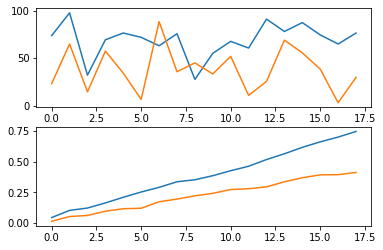

In [160]:
try:
    plt.gcf().clear()
except:
    pass
fig, axs = plt.subplots(2)
axs[0].plot(solution[0][:horizon])
axs[0].plot(solution[0][horizon:])

axs[1].plot(np.cumsum(solution[0][:horizon]*1e-6*600))
axs[1].plot(np.cumsum(solution[0][horizon:]*1e-6*600))

plt.show()

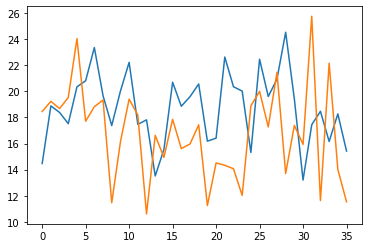

In [148]:
u = np.array([solution[0][0:horizon], solution[0][horizon:]]).transpose()
plt.plot(u[:,0])
plt.plot(u[:,1])



In [149]:
u = solution[0]
traj = traj_total_reward(x0, u, horizon,dis)

In [139]:
traj

-2358.1121171784507

In [74]:
u

array([[2.21159665, 2.54848338],
       [2.02694815, 2.19471248],
       [2.4734767 , 2.37254849],
       [2.47067294, 2.40652353],
       [2.71627511, 1.99805946],
       [1.7319947 , 1.83705028],
       [2.20723393, 2.26325401],
       [2.92374638, 2.30366645],
       [2.67719325, 2.05393459],
       [1.98245453, 2.27106395],
       [2.75636714, 1.58777204],
       [2.12670085, 1.51313922],
       [2.29996873, 1.82513434],
       [2.53303775, 1.99566608],
       [2.39384462, 2.07625416],
       [2.03173802, 2.27099692],
       [2.9182734 , 2.38018028],
       [1.96101758, 1.95964292]])

In [33]:
initial_guess = 100*np.ones((1000, 144*2), dtype = float)
initial_condition = np.array([0, 2, 50, 0, 0])
horizon = 144
constraints = ({'type': 'ineq', 'fun': lambda x:  x},
               {'type': 'ineq', 'fun': lambda x: 100 - x})
solution = minimize(fun=lambda u: traj_total_reward(initial_condition, u, 1,dis),  
                    x0 = initial_guess, 
                    constraints = constraints)
solution

C:\Users\wenap\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\numpy\core\fromnumeric.py:86: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [102]:
f = lambda u: traj_total_reward(x0, u, 1,dis)

In [101]:
f(np.array([50, 50]))

TypeError: f() missing 1 required positional argument: 'y'

In [103]:
# closed loop simulation

x0 = np.array([2.0, 0.0, 0.0]).reshape(-1,1)
simulator.x0 = x0
mpc.x0 = x0

t_end = 50
outputs = []
inputs = []
for i in range(int(t_end)):
    u0 = mpc.make_step(x0)
    x0 = simulator.make_step(u0)
    outputs.append(x0)
    inputs.append(u0)
    

NameError: name 'simulator' is not defined

In [104]:
outputs = np.concatenate(outputs, axis=1)
inputs = np.concatenate(inputs, axis=1)

NameError: name 'outputs' is not defined

In [105]:
outputs[0,11]

NameError: name 'outputs' is not defined

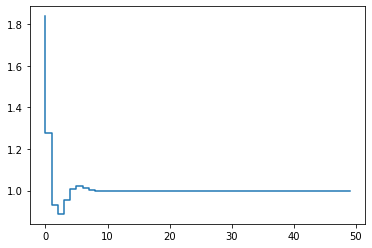

In [12]:
t = np.arange(0, t_end, 1)
plt.step(range(t_end), outputs[0,:])


In [188]:
def next_step(x0, u):
    return x0 + u

def trajectory(x0, u, horizon):
    x = x0
    states = np.zeros((x0.shape[0], horizon))
    for i in range(horizon):
        x = next_step(x, u[i])
        states[:,i] = x
    return states

def traj_reward(x0, u, horizon):
    x = x0
    ref = 1
    states = np.zeros((x0.shape[0], horizon))
    for i in range(horizon):
        x = next_step(x, u[i])
        states[:,i] = x
    return np.sum((states[0,:] - ref)**2)

horizon = 20
x0 = np.array([-1])
solution = pso(f=lambda u: traj_reward(x0, u, 10), 
            lb=np.zeros(horizon), 
            ub=np.ones(horizon)*10, 
            dim=horizon, 
            n_particles=70, 
            n_iter=200, 
            x0 = np.zeros(horizon))

solution

(array([0.22110616, 0.3202518 , 0.42142739, 0.17701618, 0.46737536,
        0.24373061, 0.18271017, 0.39025947, 0.23101077, 0.40415165,
        0.17959194, 0.45529481, 0.6426595 , 0.36499285, 0.65336863,
        0.27709106, 0.46286762, 0.60446441, 0.44305555, 0.27066465]),
 9.015639044608239)

In [189]:
a = trajectory(x0, solution[0], horizon)

a.shape


(1, 20)

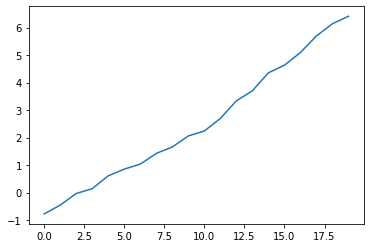

In [190]:
plt.plot(a[0])

In [3]:
from utils_functions.funcionesEMS import *
import numpy as np
import matplotlib.pyplot as plt

In [4]:
temp = get_temperatura()
demand = get_demand()
rad = get_rad()


In [7]:
sp = solar_power(rad, temp)
600/(60*60)

0.16666666666666666

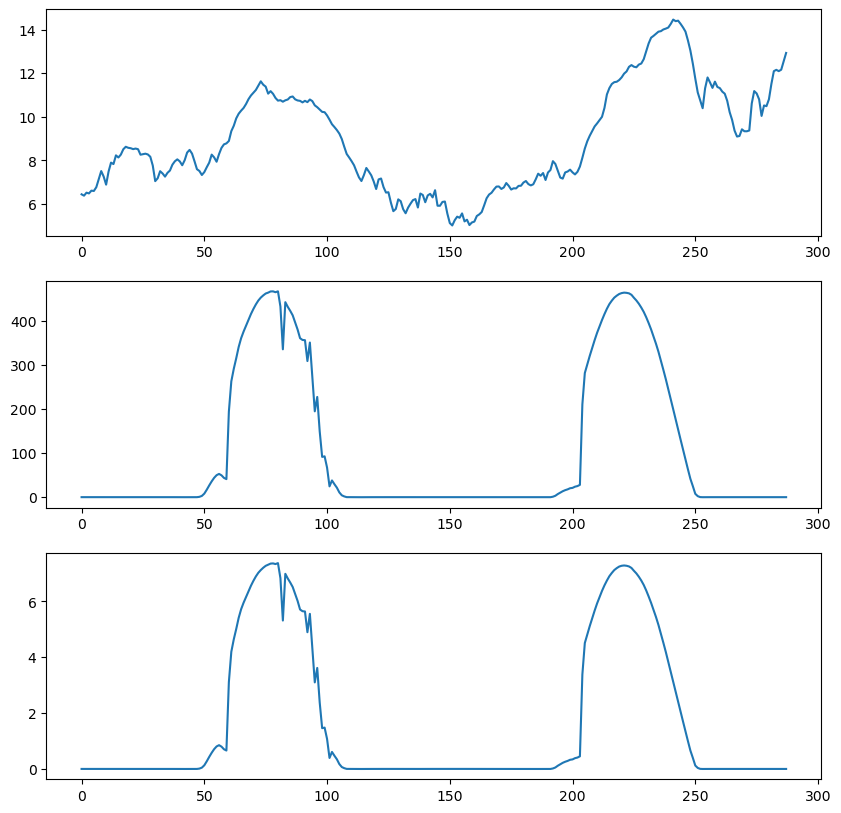

In [6]:
n = 288
fig, axs = plt.subplots(3, 1, figsize=(10,10))
axs[0].plot(temp[:n])
axs[1].plot(rad[:n])
axs[2].plot(sp[:n])




In [1]:
pip install ipyopt

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [20 lines of output]
  Traceback (most recent call last):
    File "C:\Users\wenap\.conda\envs\PPO_project\lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\wenap\.conda\envs\PPO_project\lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
    File "C:\Users\wenap\.conda\envs\PPO_project\lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 118, in get_requires_for_build_wheel
      return hook(config_settings)
    File "C:\Users\wenap\AppData\Local\Temp\pip-build-env-y9ud_1ld\overlay\Lib\site-packages\setuptools\build_meta.py", line 325, in get_requires_for_build_wheel
      return self._get_build_requires(config_settings, requirements=['wheel'])
    File "C:\U